## Import Libraries
We import all required libraries for data processing, visualization, classification, and clustering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

## Load Dataset
The dataset contains customer booking behavior and travel-related features.

In [3]:
df = pd.read_csv(r"C:\Users\arozh\OneDrive\Documents\Aromal S Prakash Educational\Amrita PG\SEM2\Advanced Data Mining\Project\customer_booking.csv", encoding="latin1")

print(df.head())

   num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2      Internet  RoundTrip            262              19   
1               1      Internet  RoundTrip            112              20   
2               2      Internet  RoundTrip            243              22   
3               1      Internet  RoundTrip             96              31   
4               2      Internet  RoundTrip             68              22   

   flight_hour flight_day   route booking_origin  wants_extra_baggage  \
0            7        Sat  AKLDEL    New Zealand                    1   
1            3        Sat  AKLDEL    New Zealand                    0   
2           17        Wed  AKLDEL          India                    1   
3            4        Sat  AKLDEL    New Zealand                    0   
4           15        Wed  AKLDEL          India                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0                     0        

### Interpretation
The dataset includes features related to booking behavior and travel preferences.

### Inference
This dataset is suitable for both classification and clustering tasks.

## Data Understanding
Analyzing structure, statistics, and missing values.

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

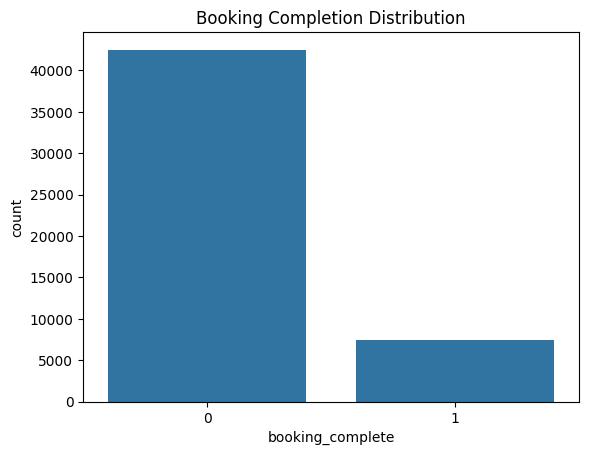

In [5]:
sns.countplot(x=df["booking_complete"])
plt.title("Booking Completion Distribution")
plt.show()

### Interpretation
The distribution shows completed vs non-completed bookings.

### Inference
Understanding distribution helps ensure balanced classification.

## Data Preprocessing
Encoding categorical variables for machine learning.

In [6]:
categorical_cols = ["sales_channel", "trip_type", "flight_day", "route", "booking_origin"]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop("booking_complete", axis=1)
y = df["booking_complete"]

### Interpretation
Categorical variables are converted into numeric format.

### Inference
Ensures compatibility with machine learning algorithms.

## Train Test Split
Splitting data into training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

### Interpretation
Data is divided into training and testing sets.

### Inference
Ensures unbiased evaluation of model performance.

## Feature Scaling
Normalizing feature values.

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Interpretation
Feature values are scaled to a common range.

### Inference
Improves performance of distance-based models like KNN.

## Classification Models
Applying multiple models to predict booking completion.

In [9]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, f1])
    predictions[name] = y_pred

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,F1 Score
4,Random Forest,0.8563,0.177447
3,SVM,0.8520,0.000000
1,KNN,0.8302,0.147590
2,Naive Bayes,0.8222,0.137730
0,Decision Tree,0.7826,0.321049


### Interpretation
Different classification models are evaluated based on performance.

### Inference
Allows identification of the most suitable model.

## Model Performance Comparison
Comparing models using Accuracy and F1 Score.

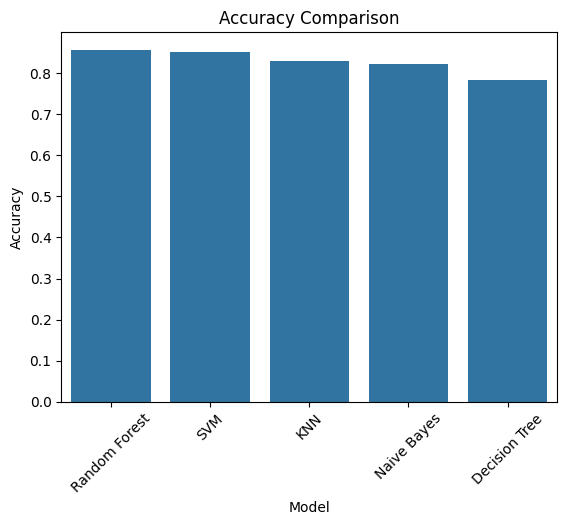

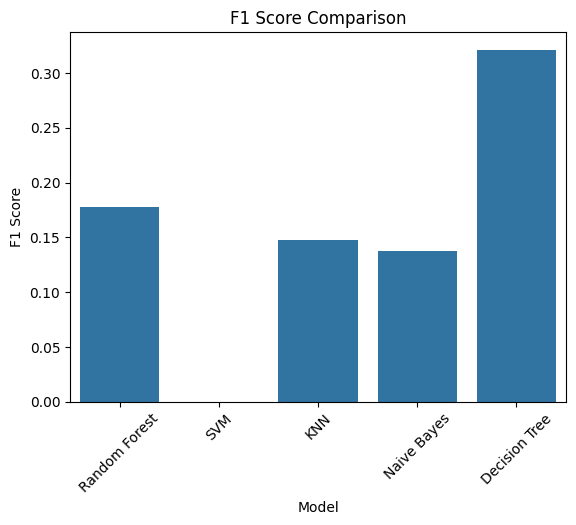

In [10]:
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

sns.barplot(x="Model", y="F1 Score", data=results_df)
plt.title("F1 Score Comparison")
plt.xticks(rotation=45)
plt.show()

### Interpretation
The graph shows performance differences among models.

### Inference
Higher values indicate better predictive performance.

#### We compare models using both Accuracy and F1 Score to ensure balanced evaluation.

In [11]:
# Combine Accuracy and F1 into one score
results_df["Final Score"] = (results_df["Accuracy"] + results_df["F1 Score"]) / 2

# Sort based on Final Score
results_df = results_df.sort_values(by="Final Score", ascending=False)

results_df

,Model,Accuracy,F1 Score,Final Score
0,Decision Tree,0.7826,0.321049,0.551825
4,Random Forest,0.8563,0.177447,0.516874
1,KNN,0.8302,0.147590,0.488895
2,Naive Bayes,0.8222,0.137730,0.479965
3,SVM,0.8520,0.000000,0.426000


### Interpretation
Models are evaluated using both Accuracy and F1 Score to provide a balanced performance measure.

### Inference
This avoids selecting models that perform well only on accuracy but poorly on class distribution.

## Top 3 Models
Selecting best models based on performance.

In [12]:
top3 = results_df.head(3)
top3

,Model,Accuracy,F1 Score,Final Score
0,Decision Tree,0.7826,0.321049,0.551825
4,Random Forest,0.8563,0.177447,0.516874
1,KNN,0.8302,0.147590,0.488895


### Interpretation
Initially, models were ranked based only on accuracy, which led to incorrect selection.

### Inference
By considering both Accuracy and F1 Score, we ensure that models perform well across all classes, leading to better model selection.

## Confusion Matrix
Evaluating prediction performance of the best model.

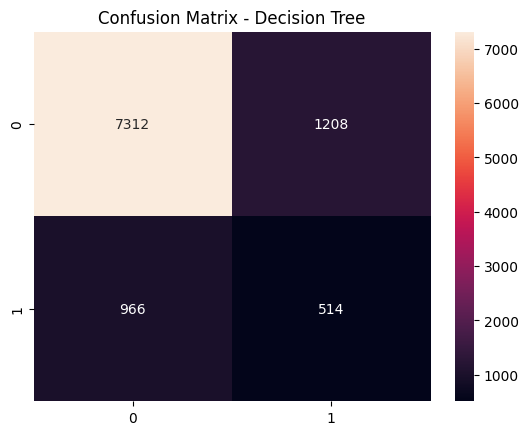

In [13]:
best_model = top3.iloc[0]["Model"]

cm = confusion_matrix(y_test, predictions[best_model])

sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Confusion Matrix - {best_model}")
plt.show()

### Interpretation
The confusion matrix shows correct and incorrect classifications made by the best-performing model.

### Inference
A balanced distribution of predictions indicates good model performance across both classes.

## Final Model Selection
Choosing the most suitable models for deployment.

In [14]:
# Final 2 models (top performers)
final_models = results_df.head(2)
final_models

,Model,Accuracy,F1 Score,Final Score
0,Decision Tree,0.7826,0.321049,0.551825
4,Random Forest,0.8563,0.177447,0.516874


### Interpretation
The top 2 models are selected as final models based on overall performance.

### Inference
These models provide the most reliable predictions and are suitable for real-world application.

## VISUAL GRAPH

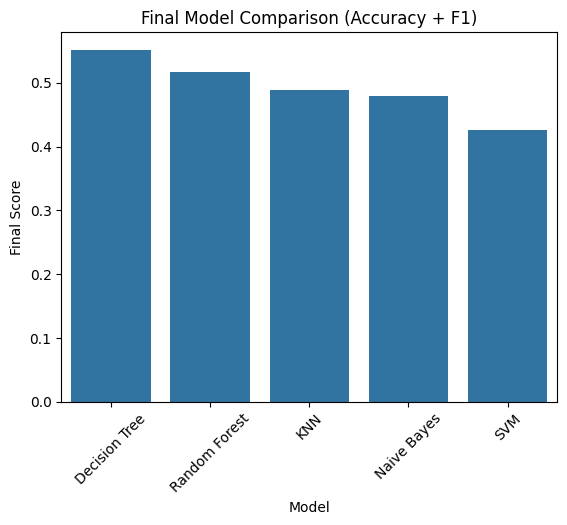

In [15]:
sns.barplot(x="Model", y="Final Score", data=results_df)
plt.title("Final Model Comparison (Accuracy + F1)")
plt.xticks(rotation=45)
plt.show()

### Interpretation
The graph shows overall model performance based on combined metrics.

### Inference
Models with higher final scores are more balanced and reliable.

## Decision Tree Visualization
Understanding how the model makes decisions step-by-step.

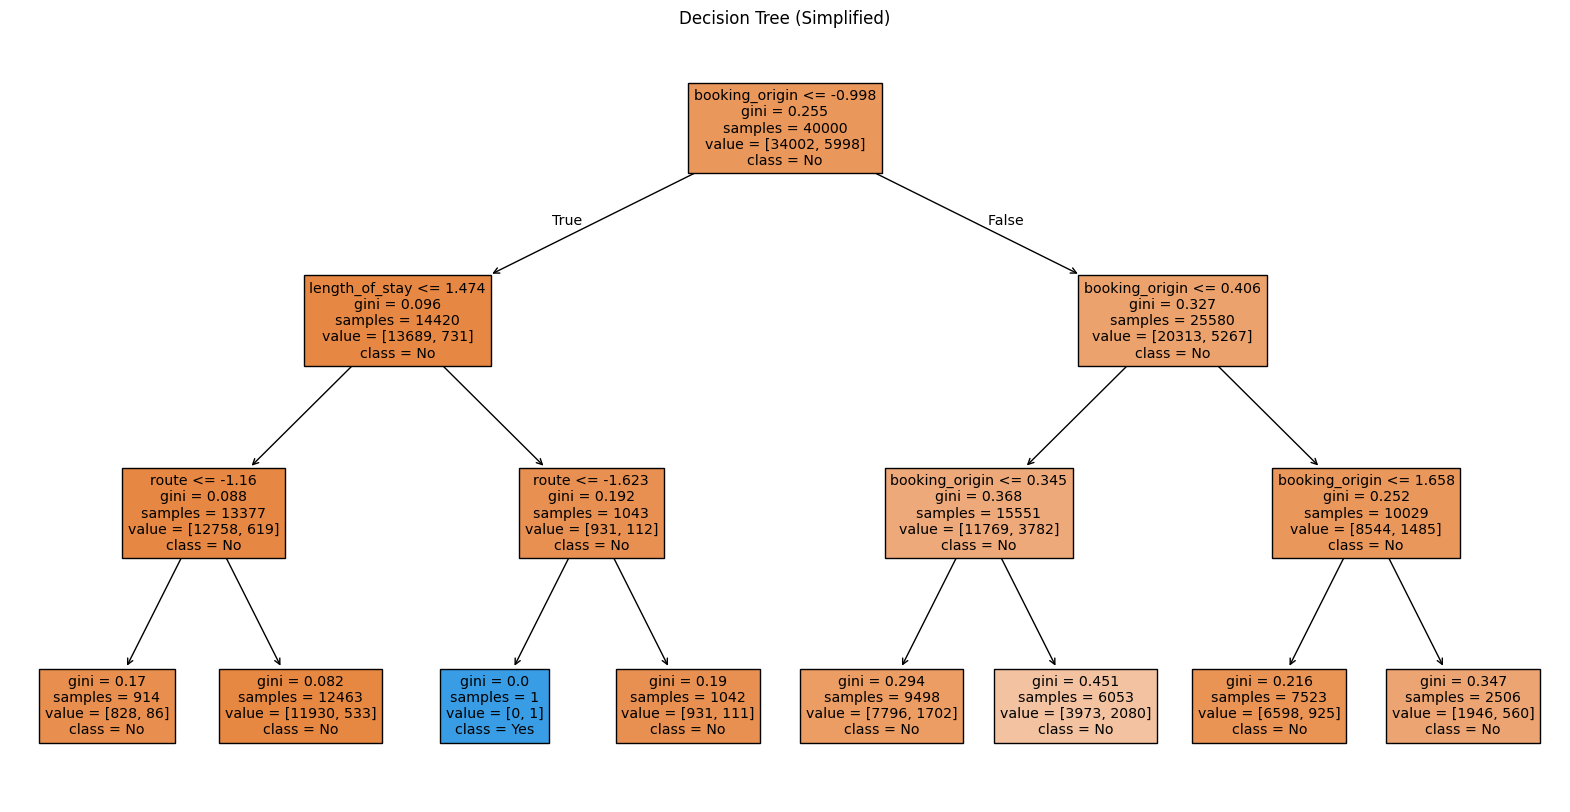

In [16]:
# Train a smaller tree for visualization
small_tree = DecisionTreeClassifier(max_depth=3)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(20,10))

plot_tree(
    small_tree,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)

plt.title("Decision Tree (Simplified)")
plt.show()

### Interpretation
The simplified decision tree shows how key features influence booking decisions.

### Inference
Limiting the depth helps in better visualization and understanding of important decision rules.

## Clustering Analysis
Applying clustering techniques to group customers based on behavior.

In [19]:
# Scale full dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

# Sample data for hierarchical clustering
sample_size = 3000 
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]

hier = AgglomerativeClustering(n_clusters=3)
h_labels = hier.fit_predict(X_sample)

### Interpretation
The clustering algorithms group customers based on similarities in their booking patterns and travel-related features.

### Inference
Clustering enables the identification of distinct customer segments, which can be useful for targeted marketing, personalization, and strategic decision-making.

## Clustering Comparison
Comparing clustering models using Silhouette Score.

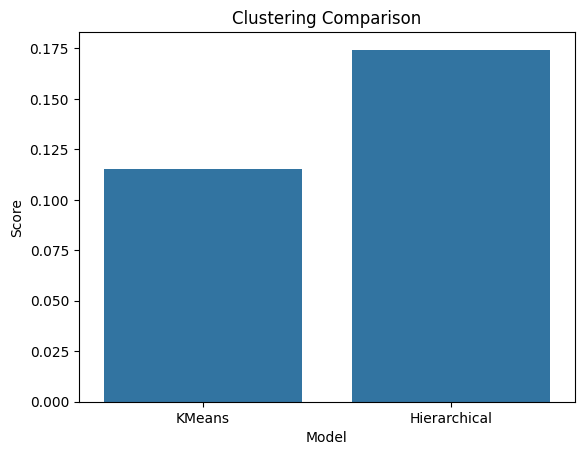

In [20]:
sil_k = silhouette_score(X_scaled, k_labels)   # full data
sil_h = silhouette_score(X_sample, h_labels)   # sample data

cluster_df = pd.DataFrame({
    "Model": ["KMeans", "Hierarchical"],
    "Score": [sil_k, sil_h]
})

cluster_df

sns.barplot(x="Model", y="Score", data=cluster_df)
plt.title("Clustering Comparison")
plt.show()

### Interpretation
Clustering models are compared based on silhouette score.

### Inference
Higher silhouette score indicates better cluster separation and more meaningful grouping.

## Best Clustering Selection
Selecting the top performing clustering algorithms.

In [ ]:
best_clusters = cluster_df.sort_values(by="Score", ascending=False).head(1)
best_clusters

,Model,Score
1,Hierarchical,0.174338


### Interpretation
The top clustering model is selected based on silhouette score.

### Inference
This model provide the most accurate and meaningful segmentation of customers.

## Dendrogram Analysis
Visualizing hierarchical clustering structure.

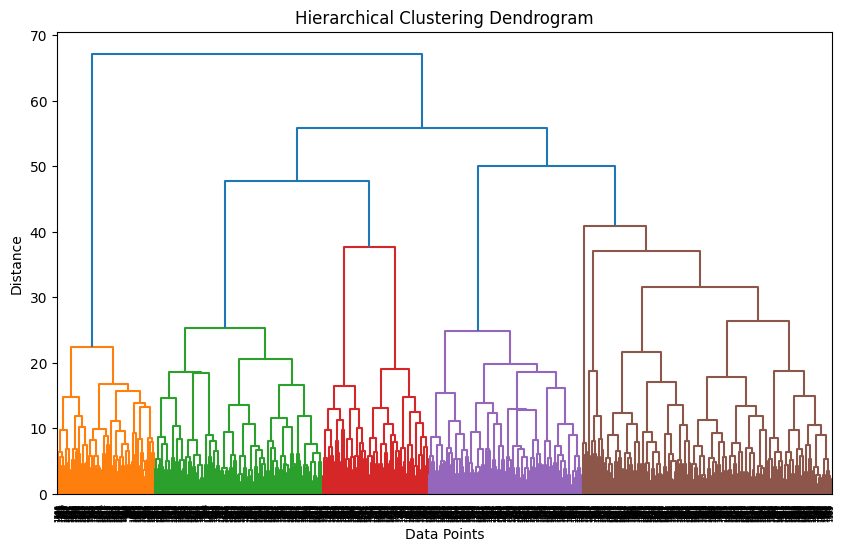

In [22]:
# Take sample from already scaled data
sample_size = 2000
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]

# Apply hierarchical linkage
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Interpretation
The dendrogram visualizes hierarchical clustering using a sample of the dataset.

### Inference
A reduced dataset was used to ensure computational feasibility while still capturing meaningful cluster relationships.

## Classification vs Clustering
Comparing supervised and unsupervised learning approaches.

In [ ]:
print("""
Classification:
- Predicts booking completion
- Uses labeled data

Clustering:
- Groups customers based on behavior
- Identifies hidden patterns
""")


Classification:
- Predicts booking completion
- Uses labeled data

Clustering:
- Groups customers based on behavior
- Identifies hidden patterns



### Interpretation
Classification focuses on predicting outcomes, while clustering groups similar data points.

### Inference
Classification is useful for prediction tasks, whereas clustering is useful for segmentation and pattern discovery.